In [ ]:
# todo: rename from optimized_signal.ipynb to make_combined_signal.ipynb

In [1]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import polars as pl

try:
    plt.style.use('/home/dy9683/cosmic-shear/cosmic-shear-with-spec-z/paperfigs.mplstyle')
except Exception as e:
    print(f'Error: {e}')

In [2]:
hscy3 = "/scratch/gpfs/dy9683/matched_catalogs/hscy3_matched_lensing_match_1.csv"
desy3 = "/scratch/gpfs/dy9683/matched_catalogs/desy3_matched_lensing_match_1.csv"
decade = "/scratch/gpfs/dy9683/matched_catalogs/decade_matched_lensing_match_1.csv"
kidslegacy = "/scratch/gpfs/dy9683/matched_catalogs/kidslegacy_matched_lensing_match_1.csv"

In [3]:
hsc_catalog = pd.read_csv(hscy3)

In [4]:
des_catalog = pd.read_csv(desy3)

In [5]:
decade_catalog = pd.read_csv(decade)

In [6]:
# prioritize galaxy if it has shape from HSC --> DES --> DECADE
# 0. check uniqueness of ID, if galaxies are repeated delete to only have one
# 1. go through ID of all three catalogs, if it exists in HSC catalog choose that one. if not then check if it exists in DES catalog.
# if not that choose DECADE shape

# Check uniquness of ID of galaxies in catalogs

In [7]:
# run code to get duplicate rows, for all the numbers choose the object with same TARGETID, choose the last (this choice is temporary)
# update catalogs
# todo: make better for loop

In [8]:
hsc_catalog = pd.read_csv(hscy3, dtype={"TARGETID": str})

duplicate_rows = hsc_catalog[hsc_catalog.duplicated(subset=["TARGETID"], keep=False)]
print("TARGETIDs with duplicates:")
print(duplicate_rows["TARGETID"].unique())

hsc_catalog_no_duplicates = hsc_catalog.drop_duplicates(subset=["TARGETID"], keep="last")
print(f"Original row count: {len(hsc_catalog)}")
print(f"Updated row count: {len(hsc_catalog_no_duplicates)}")

TARGETIDs with duplicates:
<StringArray>
['616088540131886277', '616088569823363126', '616088528190702246',
 '616088539578237300', '616088509257614427', '616088558746207241',
 '616088546058436874', '616088558146421349', '616088509878370346',
 '616088534050144428',
 ...
  '39627758107625425',  '39627776201855920',  '39627782250039260',
  '39627794333831484',  '39627800386209756',  '39627782275204229',
  '39627764151621427',  '39627758116015457',  '39627764151619387',
  '39627752063635538']
Length: 239586, dtype: str
Original row count: 1358425
Updated row count: 967581


In [9]:
des_catalog = pd.read_csv(desy3, dtype={"TARGETID": str})

duplicate_rows = des_catalog[des_catalog.duplicated(subset=["TARGETID"], keep=False)]
print("TARGETIDs with duplicates:")
print(duplicate_rows["TARGETID"].unique())

des_catalog_no_duplicates = des_catalog.drop_duplicates(subset=["TARGETID"], keep="last")
print(f"Original row count: {len(des_catalog)}")
print(f"Updated row count: {len(des_catalog_no_duplicates)}")

TARGETIDs with duplicates:
<StringArray>
['39627741842113120', '39627759961509904', '39627759961509722',
 '39627753921711220', '39627735798124194', '39627735802320158',
 '39627741842115747', '39627735798123876', '39627753921718150',
 '39627747886106510',
 ...
 '39627688746426381', '39627706844840529', '39627694786216415',
 '39627700805048013', '39627700800848193', '39627700805044829',
 '39627700805046657', '39627706832263702', '39627706836458284',
 '39627712863667866']
Length: 415197, dtype: str
Original row count: 3065015
Updated row count: 2524953


In [10]:
decade_catalog = pd.read_csv(decade, dtype={"TARGETID": str})

duplicate_rows = decade_catalog[decade_catalog.duplicated(subset=["TARGETID"], keep=False)]
print(" TARGETIDs with duplicates:")
print(duplicate_rows["TARGETID"].unique())

decade_catalog_no_duplicates = decade_catalog.drop_duplicates(subset=["TARGETID"], keep="last")
print(f"Original row count: {len(decade_catalog)}")
print(f"Updated row count: {len(decade_catalog_no_duplicates)}")

 TARGETIDs with duplicates:
<StringArray>
['2305843037764331763', '2305843037823045188',  '616088576945292007',
 '2305843038146009380', '2305843037747555989', '2305843036875132933',
 '2305843013533829908', '2305843037802073818', '2305843013533839317',
 '2305843036522813644',
 ...
   '39627749719018016',   '39627749710631437',   '39627749710632166',
   '39627755763008103',   '39627761798613872',   '39627755758817502',
   '39627755758817021',   '39627737635226966',   '39627737635227750',
   '39627731591238365']
Length: 1186260, dtype: str
Original row count: 10816067
Updated row count: 9280737


# Create Optimized Catalog (without duplicates)

In [11]:
# create final hsc catalog final, priority 1
hsc_catalog_final = hsc_catalog_no_duplicates.copy()
hsc_catalog_final['catalog'] = 'hsc' # Label HSC

# create des catalog only with galaxies that are NOT in hsc_catalog_final already
hsc_ids = hsc_catalog_no_duplicates['TARGETID'].unique()
des_catalog_filtered = des_catalog_no_duplicates[~des_catalog_no_duplicates['TARGETID'].isin(hsc_ids)]
des_catalog_filtered['catalog'] = 'des'

# create decade catalog with galaxies that are NOT in hsc_catalog_final and des_catalog_filtered
# combine the IDs from hsc and des already have
hsc_and_des_ids = set(hsc_ids).union(set(des_catalog_filtered['TARGETID'])) 
# repeat with decade what was done with des
decade_catalog_filtered = decade_catalog_no_duplicates[~decade_catalog_no_duplicates['TARGETID'].isin(hsc_and_des_ids)]
decade_catalog_filtered['catalog'] = 'decade' # Label DECADE

# combine all
optimized_catalog = pd.concat([hsc_catalog_final, des_catalog_filtered, decade_catalog_filtered], ignore_index=True)

In [13]:
optimized_catalog.to_csv("/scratch/gpfs/dy9683/matched_catalogs/hsc_des_decade_combined_lensing_match_1.csv")

In [12]:
len(optimized_catalog)

12259065

In [14]:
hsc_des_decade_counts = optimized_catalog['catalog'].value_counts()
print(hsc_des_decade_counts)

catalog
decade    8912354
des       2379130
hsc        967581
Name: count, dtype: int64


# Create Optimized Catalog (with duplicates)

In [6]:
# create final hsc catalog final, priority 1
hsc_catalog_final = hsc_catalog.copy()
hsc_catalog_final['catalog'] = 'hsc' # Label HSC

# create des catalog only with galaxies that are NOT in hsc_catalog_final already
hsc_ids = hsc_catalog['TARGETID'].unique()
des_catalog_filtered = des_catalog[~des_catalog['TARGETID'].isin(hsc_ids)]
des_catalog_filtered['catalog'] = 'des'

# create decade catalog with galaxies that are NOT in hsc_catalog_final and des_catalog_filtered
# combine the IDs from hsc and des already have
hsc_and_des_ids = set(hsc_ids).union(set(des_catalog_filtered['TARGETID'])) 
# repeat with decade what was done with des
decade_catalog_filtered = decade_catalog[~decade_catalog['TARGETID'].isin(hsc_and_des_ids)]
decade_catalog_filtered['catalog'] = 'decade' # Label DECADE

# combine all
optimized_catalog_with_duplicates = pd.concat([hsc_catalog_final, des_catalog_filtered, decade_catalog_filtered], ignore_index=True)

In [8]:
optimized_catalog_with_duplicates.to_csv("/scratch/gpfs/dy9683/matched_catalogs/hsc_des_decade_combined_with_duplicates_lensing_match_1.csv")

In [7]:
len(optimized_catalog_with_duplicates)

14538414

In [9]:
hsc_des_decade_counts_with_duplicates = optimized_catalog_with_duplicates['catalog'].value_counts()
print(hsc_des_decade_counts_with_duplicates)

catalog
decade    10309765
des        2870224
hsc        1358425
Name: count, dtype: int64


# TreeCorr Code

## Without duplicates

In [45]:
ra = optimized_catalog['TARGET_RA']
dec = optimized_catalog['TARGET_DEC']
g1 = optimized_catalog['e1'] 
g2 = optimized_catalog['e2']
z = optimized_catalog['Z_BEST']

In [46]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

## With duplicates

# Plots

## Without duplicates

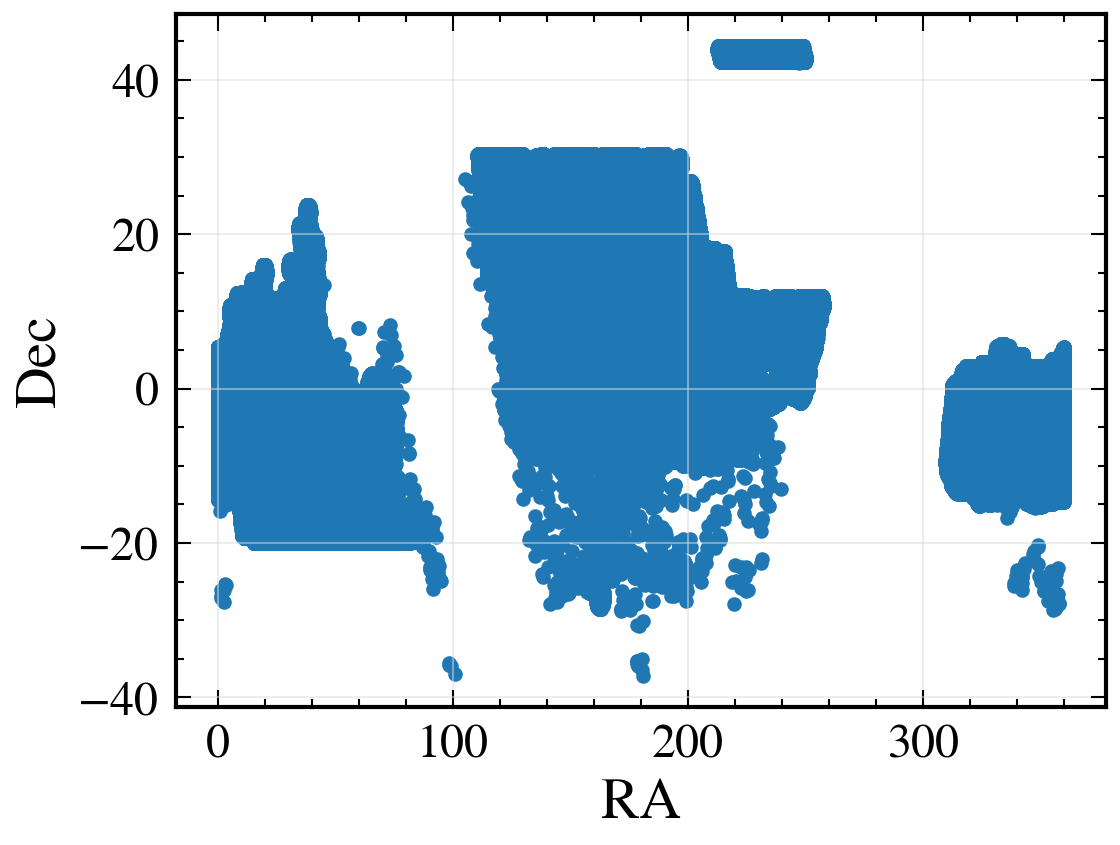

In [47]:
# ra v dec
fig, ax = plt.subplots(figsize = (8,6))
ax.scatter(ra, dec)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
#ax.set_xlim(0, 360)
#ax.set_ylim(-30, 30)
plt.show()

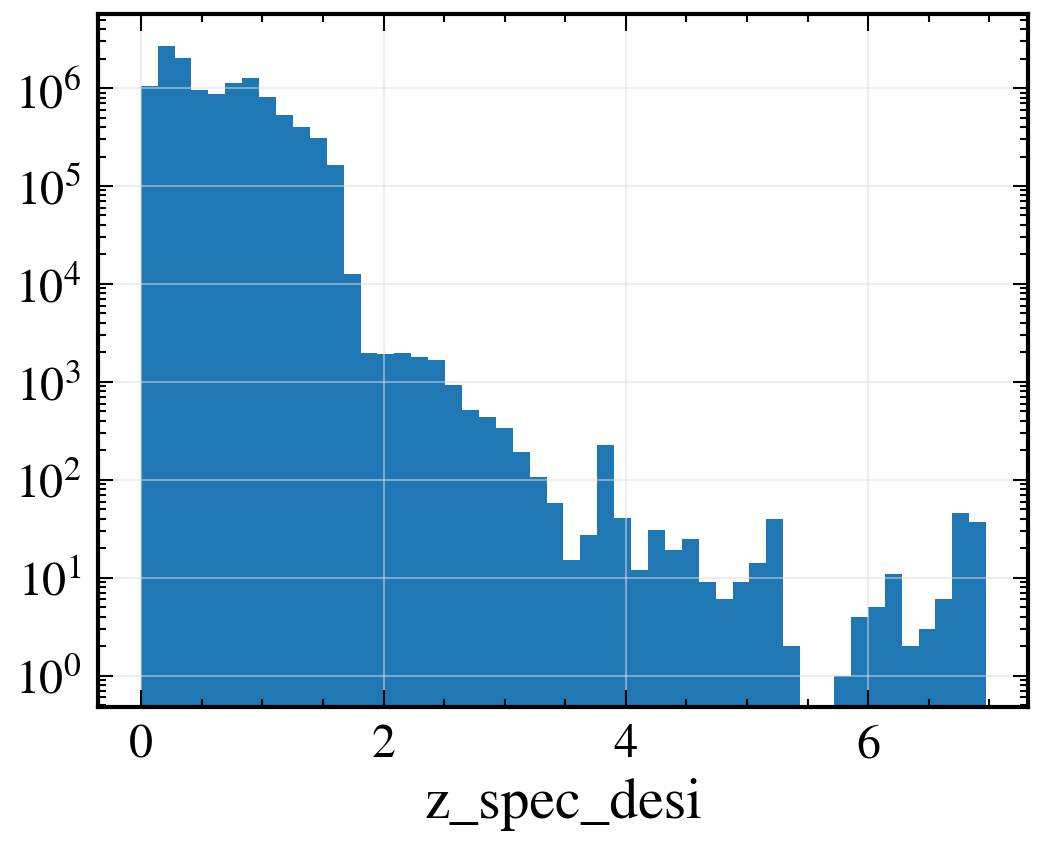

In [48]:
# histogram of redshifts
fig, ax = plt.subplots(figsize = (8,6))
ax.hist(z, bins = 50 , density = False)
ax.set_xlabel("z_spec_desi")
ax.set_yscale('log')
plt.show()

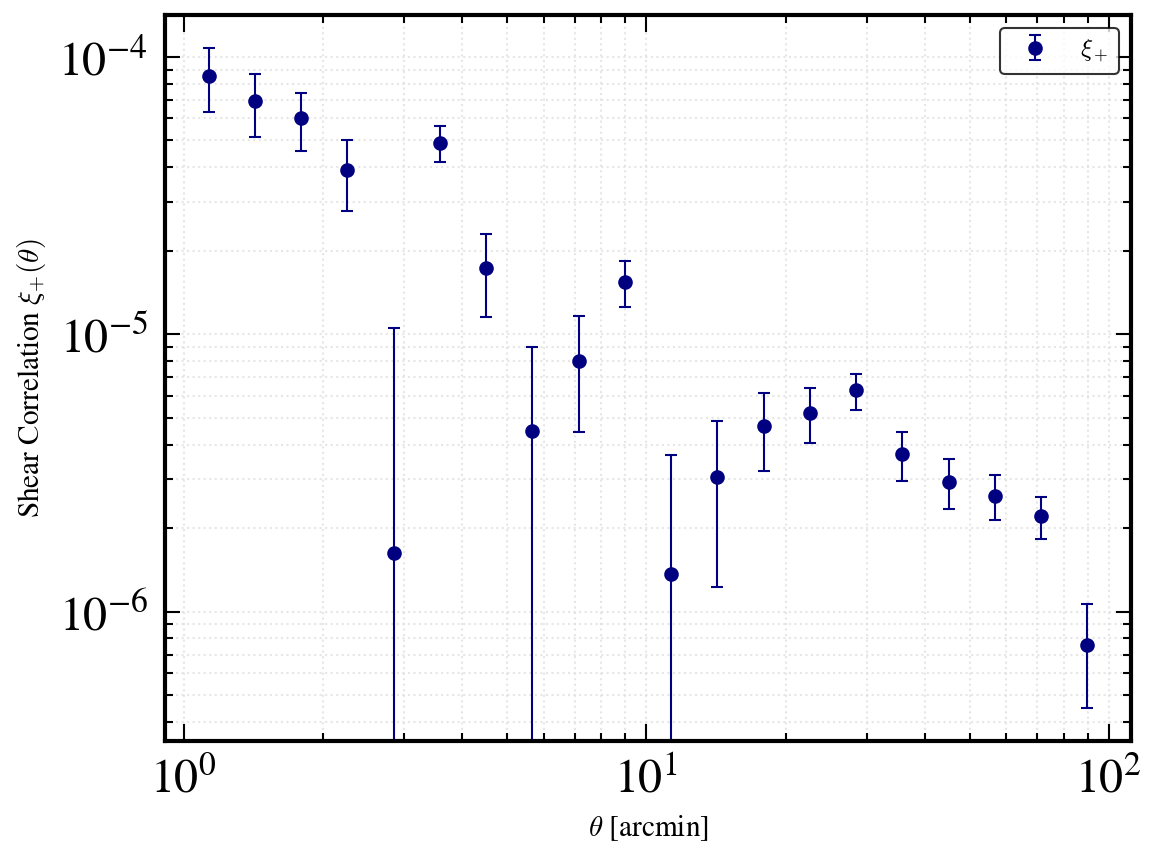

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3, fmt = "o")
#ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{+}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

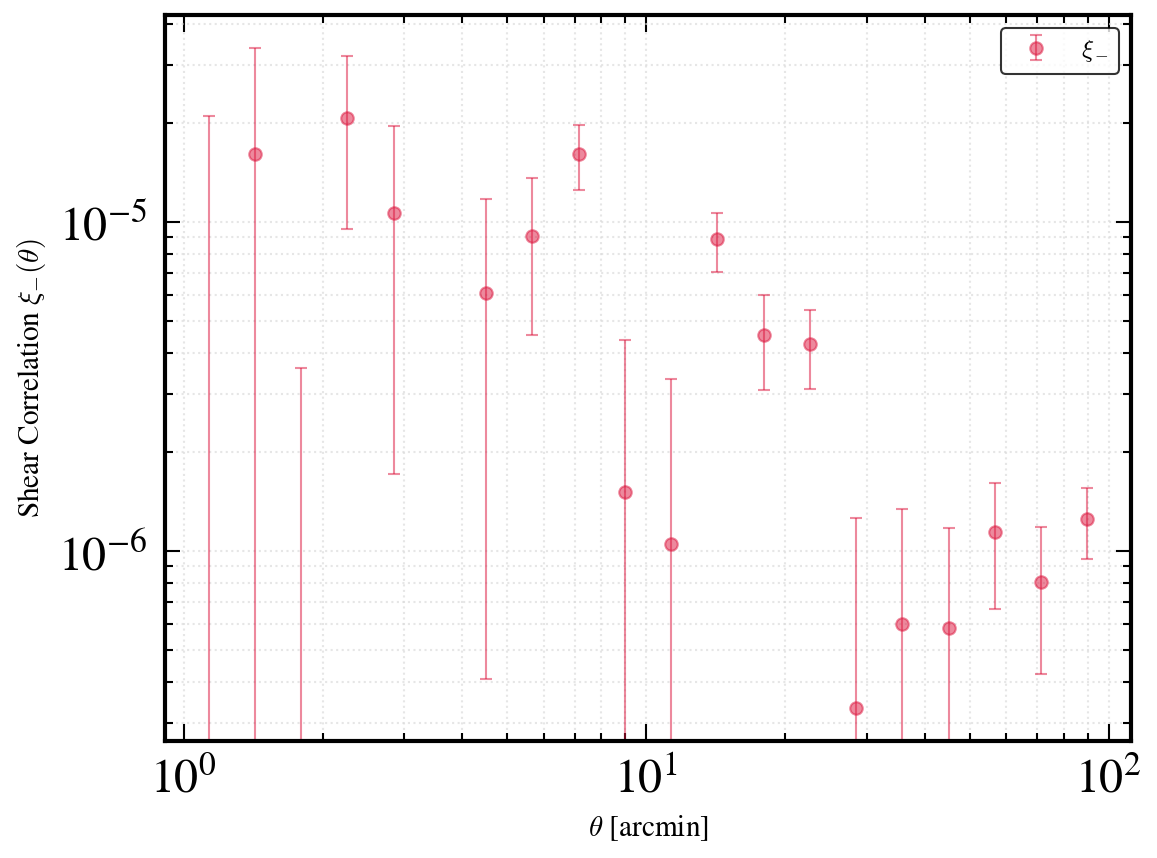

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

#ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3, fmt = "o")
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5, fmt = "o")

ax.set_xscale('log')
ax.set_yscale('log') 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{-}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## With Duplicates